# Zara Sales Dataset - Comprehensive EDA

This notebook performs a full Exploratory Data Analysis (EDA) on the Zara sales dataset to understand data structure, quality, distributions, relationships, outliers, and business implications.


Name: Abdlrhman Hisham Ismail

ID: AI2617

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style='whitegrid')


plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
pd.set_option('display.max_columns', 50)


## 1) Data Loading and Structural Audit

In [2]:
from pathlib import Path

DATA_PATH = Path('Zara_sales_EDA.csv')
assert DATA_PATH.exists(), f'Dataset not found at: {DATA_PATH.resolve()}'

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')


Shape: 20,252 rows x 17 columns
Columns: ['Product ID', 'Product Position', 'Promotion', 'Product Category', 'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description', 'price', 'currency', 'terms', 'section', 'season', 'material', 'origin']


In [3]:
# Data types and high-level schema
schema = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': [df[c].notna().sum() for c in df.columns],
    'null_count': [df[c].isna().sum() for c in df.columns],
    'n_unique': [df[c].nunique(dropna=True) for c in df.columns],
})
schema


,column,dtype,non_null_count,null_count,n_unique
0,Product ID,int64,20252,0,20252
1,Product Position,object,20252,0,3
2,Promotion,object,20252,0,2
3,Product Category,object,20252,0,1
4,Seasonal,object,20252,0,2
5,Sales Volume,int64,20252,0,1284
6,brand,object,20252,0,1
7,url,object,20252,0,228
8,name,object,20251,1,17215
9,description,object,20250,2,221


## 2) Data Quality Assessment and Cleaning Strategy

In [4]:
# Duplicates and key checks
print('Duplicate full rows:', int(df.duplicated().sum()))
print('Unique Product IDs:', df['Product ID'].nunique())
print('Total Product IDs:', len(df['Product ID']))

# Numeric validity checks
print('Negative prices:', int((df['price'] < 0).sum()))
print('Negative sales volume:', int((df['Sales Volume'] < 0).sum()))


Duplicate full rows: 0
Unique Product IDs: 20252
Total Product IDs: 20252
Negative prices: 0
Negative sales volume: 0


In [5]:
# Missing values profile
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]


,missing_count,missing_pct
description,2,0.010
name,1,0.005


In [6]:
# Standardize categorical text formatting and create cleaned copy
clean_df = df.copy()
cat_cols = clean_df.select_dtypes(include='object').columns
for c in cat_cols:
    clean_df[c] = clean_df[c].astype(str).str.strip()

# Restore true missing values after astype(str)
for c in ['name', 'description']:
    clean_df.loc[clean_df[c].str.lower().isin(['nan', 'none', '']), c] = np.nan

# Apply transparent treatment: keep rows, label missing text fields as 'Unknown'
clean_df['name'] = clean_df['name'].fillna('Unknown')
clean_df['description'] = clean_df['description'].fillna('Unknown')

# Consistency checks for Yes/No style fields
for c in ['Promotion', 'Seasonal']:
    print(c, sorted(clean_df[c].dropna().unique()))

print('Currency unique values:', clean_df['currency'].unique())


Promotion ['No', 'Yes']
Seasonal ['No', 'Yes']
Currency unique values: ['USD']


## 3) Univariate Analysis

In [7]:
# Numeric summaries
clean_df[['price', 'Sales Volume']].describe().T


,count,mean,std,min,25%,50%,75%,max
price,20252.0,41.949061,23.380960,12.0,23.95,35.95,53.95,134.99
Sales Volume,20252.0,1097.400454,298.234609,518.0,849.00,990.00,1364.25,1940.00


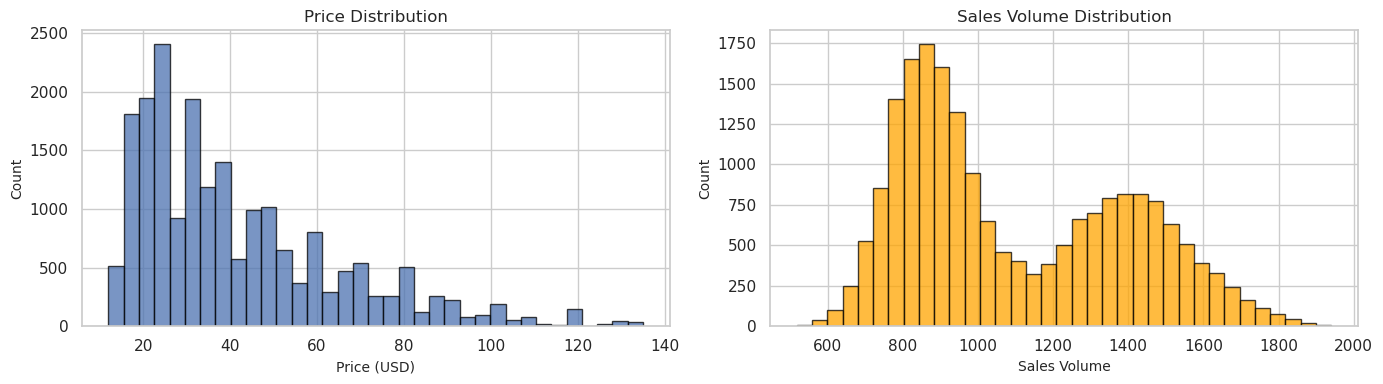

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(clean_df['price'], bins=35, edgecolor='black', alpha=0.75)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(clean_df['Sales Volume'], bins=35, edgecolor='black', alpha=0.75, color='orange')
axes[1].set_title('Sales Volume Distribution')
axes[1].set_xlabel('Sales Volume')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


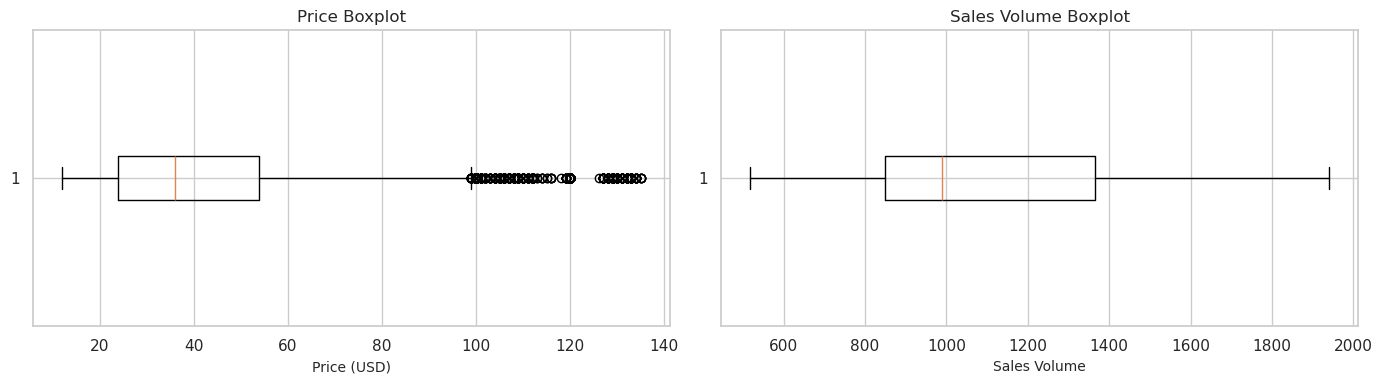

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(clean_df['price'], vert=False)
axes[0].set_title('Price Boxplot')
axes[0].set_xlabel('Price (USD)')

axes[1].boxplot(clean_df['Sales Volume'], vert=False)
axes[1].set_title('Sales Volume Boxplot')
axes[1].set_xlabel('Sales Volume')
plt.tight_layout()
plt.show()


In [10]:
# Categorical distributions (top levels)
cat_targets = ['Product Position', 'Promotion', 'Product Category', 'section', 'season', 'material', 'origin', 'terms']
for c in cat_targets:
    print(f'\n===== {c} =====')
    display(clean_df[c].value_counts(dropna=False).head(10).to_frame('count'))



===== Product Position =====


,count
Product Position,
Aisle,7810
End-cap,6791
Front of Store,5651



===== Promotion =====


,count
Promotion,
No,11812
Yes,8440



===== Product Category =====


...

,count
material,
Cotton,3851
Wool,3805
Wool Blend,3373
Polyester,2775
Linen,2573
Denim,1027
Viscose,990
Acrylic,881
Linen Blend,807



===== origin =====


,count
origin,
China,4026
Bangladesh,3617
Turkey,2475
India,2033
Morocco,1653
Portugal,1420
Spain,1248
Vietnam,1220
Cambodia,981



===== terms =====


,count
terms,
jackets,11232
sweaters,3257
t-shirts,2646
shoes,2458
jeans,659


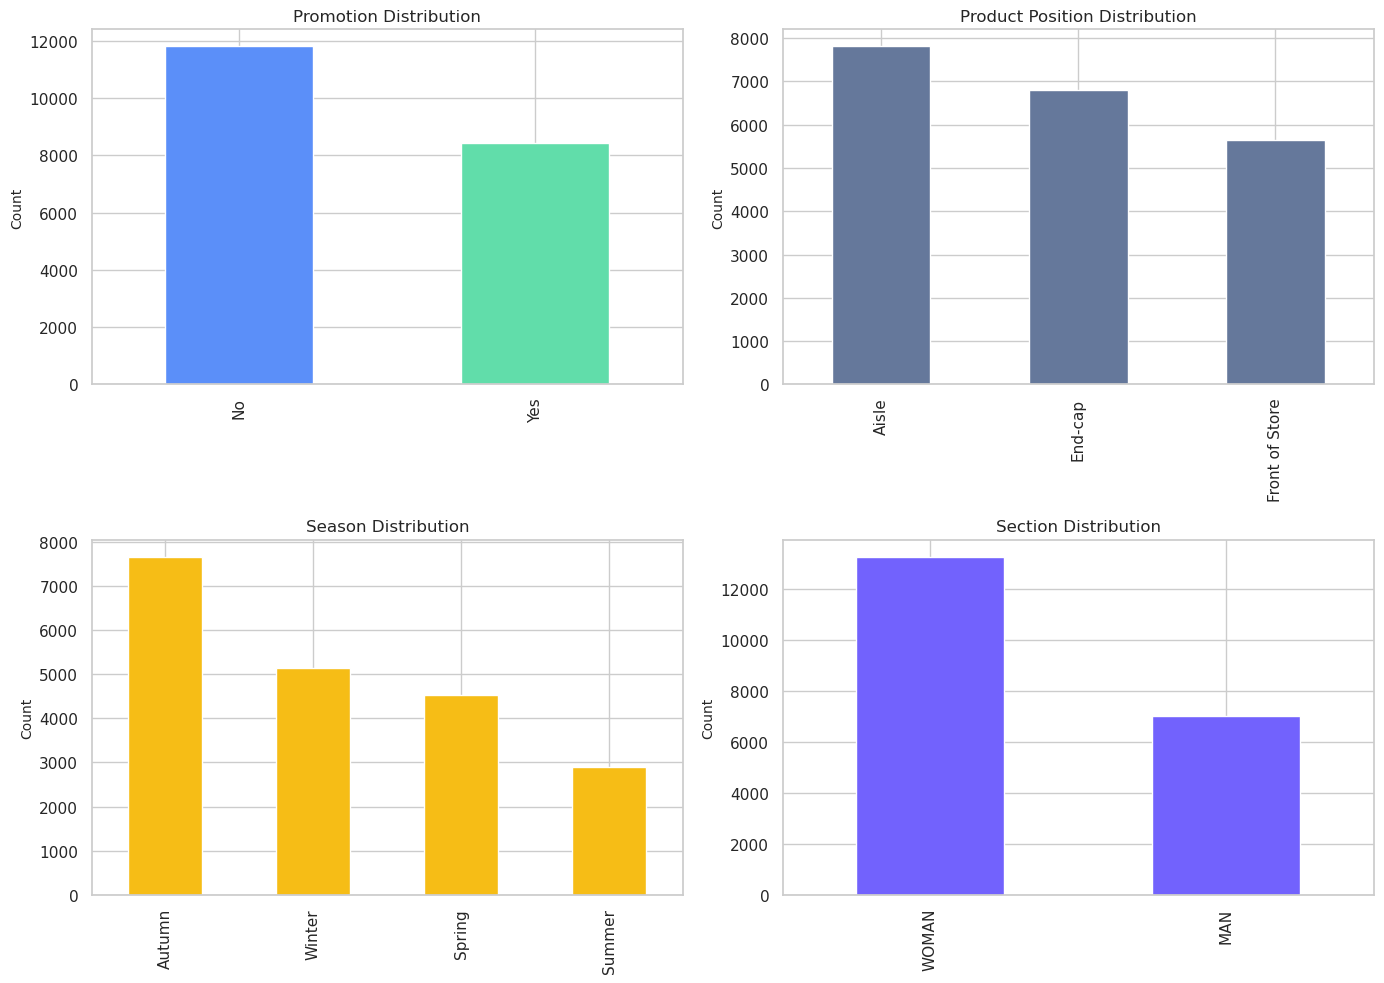

In [11]:
# Plot key categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

clean_df['Promotion'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#5B8FF9', '#61DDAA'])
axes[0, 0].set_title('Promotion Distribution')
axes[0, 0].set_ylabel('Count')

clean_df['Product Position'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#65789B')
axes[0, 1].set_title('Product Position Distribution')
axes[0, 1].set_ylabel('Count')

clean_df['season'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#F6BD16')
axes[1, 0].set_title('Season Distribution')
axes[1, 0].set_ylabel('Count')

clean_df['section'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#7262FD')
axes[1, 1].set_title('Section Distribution')
axes[1, 1].set_ylabel('Count')

for ax in axes.ravel():
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


## 4) Bivariate and Multivariate Analysis

In [12]:
# Correlation matrix for numeric fields
num_cols = clean_df.select_dtypes(include=[np.number]).columns
corr = clean_df[num_cols].corr()
corr


,Product ID,Sales Volume,price
Product ID,1.000000,-0.01109,0.000899
Sales Volume,-0.011090,1.00000,-0.337780
price,0.000899,-0.33778,1.000000


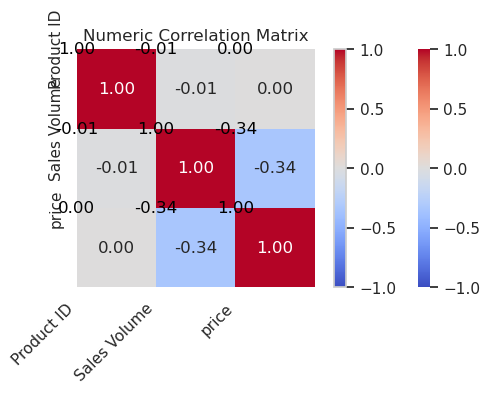

In [13]:
# Correlation heatmap (with seaborn fallback)
plt.figure(figsize=(6, 4))
sns.heatmap(corr,annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', color='black')
plt.colorbar()
plt.title('Numeric Correlation Matrix')
plt.tight_layout()
plt.show()


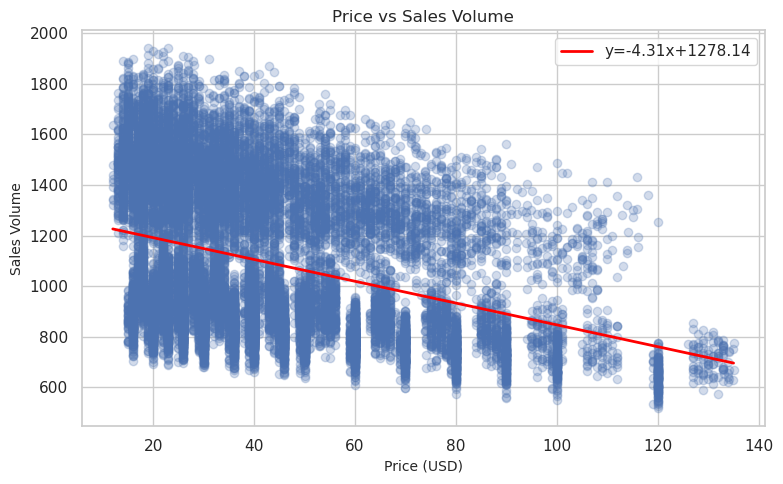

In [14]:
# Scatter plot: price vs sales volume
plt.figure(figsize=(8, 5))
plt.scatter(clean_df['price'], clean_df['Sales Volume'], alpha=0.25)
plt.title('Price vs Sales Volume')
plt.xlabel('Price (USD)')
plt.ylabel('Sales Volume')

# Add simple linear trend line
x = clean_df['price'].values
y = clean_df['Sales Volume'].values
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, trend(xs), color='red', linewidth=2, label=f'y={coef[0]:.2f}x+{coef[1]:.2f}')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Promotion impact on sales volume
promo_stats = clean_df.groupby('Promotion')['Sales Volume'].agg(['count', 'mean', 'median', 'std']).round(2)
promo_stats


,count,mean,median,std
Promotion,,,,
No,11812,872.38,868.0,108.76
Yes,8440,1412.33,1406.0,163.77


In [16]:
# Grouped comparisons for section, season, and position
section_stats = clean_df.groupby('section')[['price', 'Sales Volume']].agg(['mean', 'median']).round(2)
season_stats = clean_df.groupby('season')[['price', 'Sales Volume']].agg(['mean', 'median']).round(2)
position_stats = clean_df.groupby('Product Position')[['price', 'Sales Volume']].agg(['mean', 'median']).round(2)

print('Section stats')
display(section_stats)
print('Season stats')
display(season_stats)
print('Product Position stats')
display(position_stats)


Section stats


price        Sales Volume        
          mean median         mean  median
section                                   
MAN      42.13  35.95      1023.64   914.0
WOMAN    41.86  35.95      1136.35  1018.0

Season stats


price        Sales Volume        
         mean median         mean  median
season                                   
Autumn  40.53  35.00      1042.82   926.0
Spring  40.74  35.95      1046.22   928.0
Summer  44.08  37.99      1184.59  1059.0
Winter  43.93  36.99      1174.61  1046.0

Product Position stats


price        Sales Volume       
                   mean median         mean median
Product Position                                  
Aisle             42.12  35.95      1090.43  979.0
End-cap           41.71  35.95      1100.46  995.0
Front of Store    41.99  35.95      1103.36  999.0

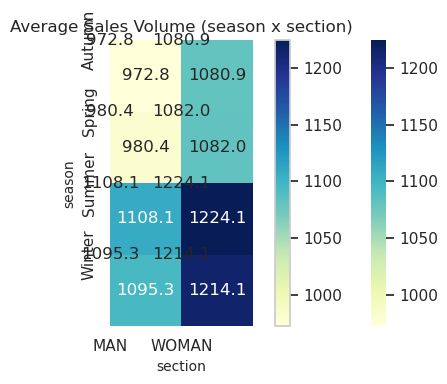

section,MAN,WOMAN
season,,
Autumn,972.84,1080.90
Spring,980.41,1081.97
Summer,1108.08,1224.12
Winter,1095.35,1214.08


In [17]:
# Pivot/heatmap: average sales by season x section
pivot_sales = clean_df.pivot_table(index='season', columns='section', values='Sales Volume', aggfunc='mean')

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_sales, annot=True, fmt='.1f', cmap='YlGnBu')
plt.imshow(pivot_sales.values, cmap='YlGnBu')
plt.xticks(range(len(pivot_sales.columns)), pivot_sales.columns)
plt.yticks(range(len(pivot_sales.index)), pivot_sales.index)
for i in range(len(pivot_sales.index)):
    for j in range(len(pivot_sales.columns)):
            plt.text(j, i, f'{pivot_sales.values[i,j]:.1f}', ha='center', va='center')
plt.colorbar()
plt.title('Average Sales Volume (season x section)')
plt.tight_layout()
plt.show()

pivot_sales.round(2)


## 5) Outlier and Anomaly Detection

In [18]:
def iqr_outlier_mask(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return mask, low, high

price_mask, price_low, price_high = iqr_outlier_mask(clean_df['price'])
sales_mask, sales_low, sales_high = iqr_outlier_mask(clean_df['Sales Volume'])

outlier_summary = pd.DataFrame({
    'variable': ['price', 'Sales Volume'],
    'low_bound': [price_low, sales_low],
    'high_bound': [price_high, sales_high],
    'outlier_count': [int(price_mask.sum()), int(sales_mask.sum())],
    'outlier_pct': [round(price_mask.mean() * 100, 2), round(sales_mask.mean() * 100, 2)]
})
outlier_summary


,variable,low_bound,high_bound,outlier_count,outlier_pct
0,price,-21.050,98.950,641,3.17
1,Sales Volume,76.125,2137.125,0,0.00


In [19]:
# Potential anomalies based on quantile rules
p90_price = clean_df['price'].quantile(0.90)
p10_price = clean_df['price'].quantile(0.10)
p90_sales = clean_df['Sales Volume'].quantile(0.90)
p10_sales = clean_df['Sales Volume'].quantile(0.10)

high_price_low_sales = clean_df[(clean_df['price'] >= p90_price) & (clean_df['Sales Volume'] <= p10_sales)]
low_price_high_sales = clean_df[(clean_df['price'] <= p10_price) & (clean_df['Sales Volume'] >= p90_sales)]

print('High-price / low-sales anomalies:', len(high_price_low_sales))
print('Low-price / high-sales anomalies:', len(low_price_high_sales))

# Show samples
print('\nSample high-price / low-sales anomalies')
display(high_price_low_sales[['Product ID', 'name', 'price', 'Sales Volume', 'Promotion', 'terms', 'season']].head(10))

print('Sample low-price / high-sales anomalies')
display(low_price_high_sales[['Product ID', 'name', 'price', 'Sales Volume', 'Promotion', 'terms', 'season']].head(10))


High-price / low-sales anomalies: 883
Low-price / high-sales anomalies: 521

Sample high-price / low-sales anomalies


,Product ID,name,price,Sales Volume,Promotion,terms,season
6,189118,FAUX LEATHER PUFFER JACKET,87.99,688,No,jackets,Winter
42,133757,POCKET PUFFER JACKET,99.99,663,No,jackets,Autumn
69,182362,CROPPED OVERSHIRT,89.95,723,No,jackets,Spring
80,125409,POCKET DENIM JACKET,99.99,687,No,jackets,Autumn
93,187180,HOODED TECHNICAL JACKET,79.95,708,No,jackets,Autumn
121,175927,ZIPPERED WOOL BLEND OVERSHIRT,98.95,738,No,jackets,Winter
138,127644,TOPSTITCH SNEAKERS,129.99,694,No,shoes,Winter
159,146804,SUEDE SNEAKERS,130.99,691,No,shoes,Summer
180,185809,KNIT SWEATER WITH RIPS,99.99,694,No,sweaters,Autumn
197,175584,BAGGY FIT JEANS LIMITED EDITION,79.99,752,No,jeans,Autumn


Sample low-price / high-sales anomalies


,Product ID,name,price,Sales Volume,Promotion,terms,season
11,140028,OVERSIZED CROPPED JACKET LIMITED EDITION,15.95,1538,Yes,jackets,Autumn
36,194339,FAUX SUEDE JACKET,16.99,1575,Yes,jackets,Autumn
94,167640,HOODED TECHNICAL JACKET,12.95,1620,Yes,jackets,Autumn
98,133078,PADDED BOMBER JACKET,16.95,1827,Yes,jackets,Winter
116,152871,TEXTURED POCKET OVERSHIRT,17.99,1677,Yes,jackets,Winter
173,181502,SOFT JEWEL SWEATER,18.95,1663,Yes,sweaters,Winter
205,172816,TEXTURED SWEATER,17.99,1528,Yes,sweaters,Winter
226,130321,ABSTRACT PRINT KNIT T-SHIRT,14.99,1833,Yes,t-shirts,Summer
237,123047,SUIT JACKET IN 100% LINEN,17.95,1534,Yes,t-shirts,Spring
313,199693,CROPPED FAUX SUEDE PATCH JACKET GREY,16.99,1589,Yes,jackets,Spring


In [20]:
# Compare key metrics with/without price outliers (impact assessment)
base_metrics = clean_df[['price', 'Sales Volume']].agg(['mean', 'median']).T
trimmed_metrics = clean_df.loc[~price_mask, ['price', 'Sales Volume']].agg(['mean', 'median']).T

impact = base_metrics.join(trimmed_metrics, lsuffix='_all', rsuffix='_without_price_outliers')
impact


,mean_all,median_all,mean_without_price_outliers,median_without_price_outliers
price,41.949061,35.95,39.668989,34.0
Sales Volume,1097.400454,990.00,1107.293968,1000.0


## 6) Key Findings and Business Insights

In [21]:
findings = {
    'records': len(clean_df),
    'features': clean_df.shape[1],
    'corr_price_sales': clean_df['price'].corr(clean_df['Sales Volume']),
    'mean_sales_promo_yes': clean_df.query("Promotion == 'Yes'")['Sales Volume'].mean(),
    'mean_sales_promo_no': clean_df.query("Promotion == 'No'")['Sales Volume'].mean(),
    'best_position': clean_df.groupby('Product Position')['Sales Volume'].mean().idxmax(),
    'best_position_sales': clean_df.groupby('Product Position')['Sales Volume'].mean().max(),
    'best_season': clean_df.groupby('season')['Sales Volume'].mean().idxmax(),
    'best_season_sales': clean_df.groupby('season')['Sales Volume'].mean().max(),
    'best_section': clean_df.groupby('section')['Sales Volume'].mean().idxmax(),
    'best_section_sales': clean_df.groupby('section')['Sales Volume'].mean().max(),
}

for k, v in findings.items():
    if isinstance(v, float):
        print(f'{k}: {v:.2f}')
    else:
        print(f'{k}: {v}')


records: 20252
features: 17
corr_price_sales: -0.34
mean_sales_promo_yes: 1412.33
mean_sales_promo_no: 872.38
best_position: Front of Store
best_position_sales: 1103.36
best_season: Summer
best_season_sales: 1184.59
best_section: WOMAN
best_section_sales: 1136.35


### Insight Interpretation (Narrative)

- **Promotion effect is strong**: promoted items show materially higher average sales volume than non-promoted items.
- **Price and sales are moderately negatively related**: higher prices generally align with lower volume, but not perfectly.
- **Seasonality matters**: Summer and Winter show stronger average demand than Spring and Autumn.
- **Placement helps**: `Front of Store` and `End-cap` slightly outperform `Aisle` in average sales.
- **Outliers are concentrated in price**: sales volume outliers are minimal using IQR, while high-price points form a visible upper-tail segment.


## 7) Final Analytical Summary

This EDA confirms that the Zara dataset is largely clean and structurally reliable (no duplicate rows, complete key numeric fields, and minor text-field missingness). The analysis shows a meaningful relationship between pricing and demand, a pronounced promotion uplift, and seasonal as well as placement-driven performance variation. Outlier diagnostics indicate that unusual behavior is mostly price-driven rather than volume-driven, suggesting pricing segmentation opportunities rather than widespread data integrity issues.

**Recommended actions:**
1. Prioritize promotional campaigns on segments with proven elasticity and high volume potential.
2. Optimize high-visibility placement (`Front of Store`, `End-cap`) for strategic SKUs.
3. Apply season-aware assortment and pricing strategy, especially for Summer/Winter peaks.
4. Deep-dive high-price/low-sales anomalies for potential markdown or repositioning opportunities.
